
# **Lasso Regression & LassoCV**

Lasso Regression (Least Absolute Shrinkage and Selection Operator) is a regularized version of Linear Regression that uses **L1 Regularization** to improve model performance. By adding a penalty to the loss function, Lasso reduces the magnitude of regression coefficients and can shrink some coefficients exactly to zero. This makes it an effective technique for **feature selection**, helping to remove less important features while reducing overfitting.

Choosing the correct regularization strength (**alpha**) is important because it directly affects the model's complexity and predictive performance. Instead of selecting alpha manually, **LassoCV** automatically determines the optimal alpha value using **Cross-Validation**, resulting in a more reliable and well-generalized model.

In this notebook, we will implement both **Lasso Regression** and **LassoCV**, evaluate their performance using different regression metrics, compare their results, and understand how regularization influences model complexity and feature selection.

---

## **Objectives**

* Understand the concept of **L1 Regularization**.
* Implement **Lasso Regression** using Scikit-learn.
* Perform **feature scaling** before training the model.
* Train and evaluate a Lasso Regression model.
* Understand how Lasso performs **automatic feature selection**.
* Implement **LassoCV** to automatically find the optimal value of alpha.
* Interpret important attributes such as `alpha_` and `mse_path_`.
* Visualize model predictions and feature coefficients.
* Compare the performance of **Lasso Regression** and **LassoCV** using evaluation metrics.

In [ ]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI New folder/Algerian_forest_fires_cleaned_dataset.csv')

In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df.drop(columns=["day", "month", "year"], inplace=True)

In [ ]:
df["Classes"] = np.where(
    df["Classes"].str.strip().str.lower() == "not fire",
    0,
    1
)

In [ ]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [ ]:
df["Classes"].value_counts()

,count
Classes,
1,137
0,106


**Divide Dataset into Independent and Dependent Features**

In [ ]:
X = df.drop(columns=["FWI"])
y = df["FWI"]

In [ ]:
print("Independent Features (X):")
display(X.head())

print("\nDependent Feature (y):")
display(y.head())

Independent Features (X):


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0



Dependent Feature (y):


,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5


In [ ]:
# Split the Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

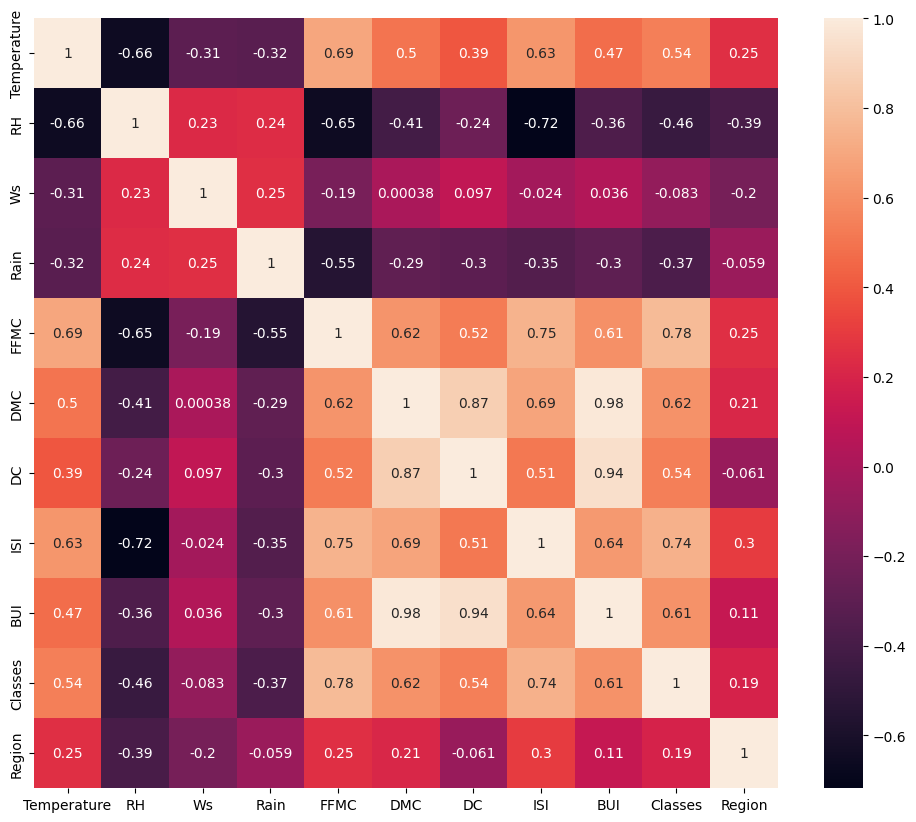

In [ ]:
# Feature Selection Based on Correlation
import seaborn as sns
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
# Function to identify highly correlated features
def correlation(dataset, threshold):
    """
    Returns a set of feature names whose absolute
    correlation is greater than the specified threshold.
    """

    # Store features to remove
    col_corr = set()

    # Calculate correlation matrix
    corr_matrix = dataset.corr()

    # Compare every pair of features
    for i in range(len(corr_matrix.columns)):
        for j in range(i):

            # Check absolute correlation value
            if abs(corr_matrix.iloc[i, j]) > threshold:

                # Store the feature name
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

In [ ]:
# Find highly correlated features
corr_features = correlation(X_train, threshold=0.85)

print(corr_features)

{'DC', 'BUI'}


In [ ]:
# Remove highly correlated features from both datasets

X_train = X_train.drop(columns=corr_features)
X_test = X_test.drop(columns=corr_features)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Lasso Regression uses L1 Regularization, which penalizes coefficients based on their magnitude. Since features may have different units and scales, feature scaling is necessary to ensure that all features contribute equally to the regularization process.

# **Train Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

Lasso Regression applies an L1 penalty to the loss function. As the value of alpha increases, the penalty becomes stronger, forcing less important feature coefficients toward zero. This helps perform automatic feature selection and reduces overfitting.

In [ ]:
# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"Mean Absolute Error : {lasso_mae:.3f}")
print(f"Mean Squared Error  : {lasso_mse:.3f}")
print(f"R² Score            : {lasso_r2:.3f}")

Mean Absolute Error : 1.133
Mean Squared Error  : 2.248
R² Score            : 0.949


In [ ]:
# Create a DataFrame of feature coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso.coef_
})

# Sort by absolute coefficient values
coef_df = coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coef_df

,Feature,Coefficient
6,ISI,4.008247
5,DMC,2.990252
0,Temperature,0.000000
1,RH,-0.000000
2,Ws,0.000000
4,FFMC,0.000000
3,Rain,-0.000000
7,Classes,0.000000
8,Region,-0.000000


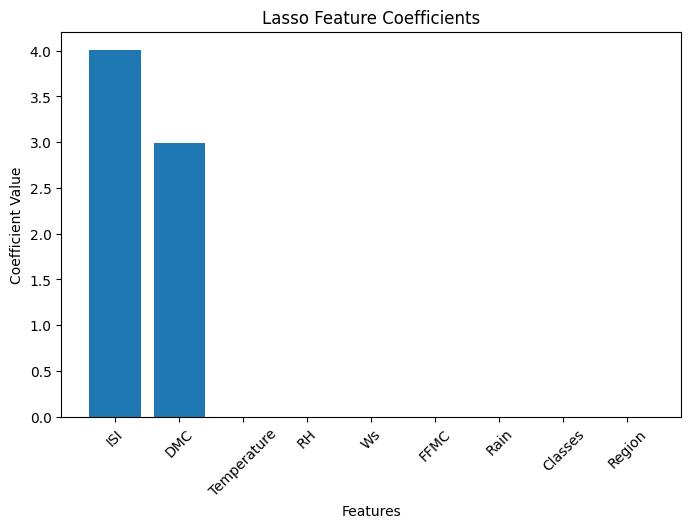

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Lasso Feature Coefficients")

plt.show()

In [ ]:
# Features removed by Lasso
print("Features with Zero Coefficients:\n")
print(coef_df[coef_df["Coefficient"] == 0])

Features with Zero Coefficients:

       Feature  Coefficient
0  Temperature          0.0
1           RH         -0.0
2           Ws          0.0
4         FFMC          0.0
3         Rain         -0.0
7      Classes          0.0
8       Region         -0.0


Lasso Regression can shrink some coefficients exactly to zero. Features with a coefficient of 0 are effectively removed from the model, making Lasso an embedded feature selection technique.

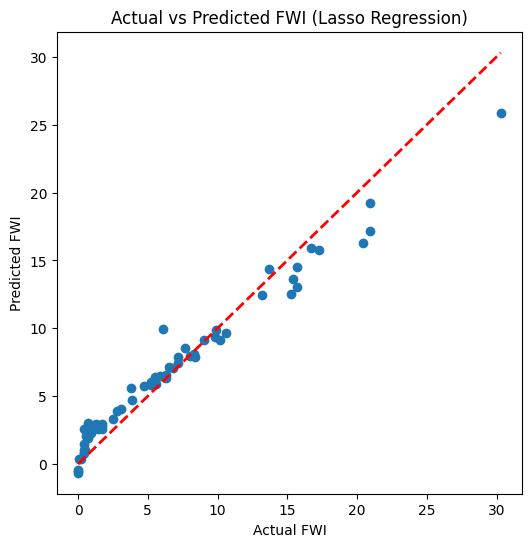

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, lasso_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (Lasso Regression)")

plt.show()

This plot is an **Actual vs Predicted** scatter plot used to evaluate your **Lasso Regression model**.

* **X-axis (Actual FWI):** The true Fire Weather Index values from the test dataset.
* **Y-axis (Predicted FWI):** The values predicted by the Lasso Regression model.

Each blue dot represents **one test sample**.

For example:

| Actual FWI | Predicted FWI |
| ---------- | ------------- |
| 5.0        | 5.3           |
| 10.0       | 9.8           |
| 21.0       | 19.2          |
| 30.0       | 26.0          |

---

**What does this graph tell us?**

Ideally, every point should lie on the line:


Predicted FWI = Actual FWI


If you draw a diagonal line from the bottom-left to the top-right:

* Points **on the line** ? Perfect predictions.
* Points **close to the line** ? Small prediction errors.
* Points **far from the line** ? Larger prediction errors.

---
### **Interpretation of your graph**

Most points are clustered very close to the imaginary diagonal line.

This indicates that:

* The Lasso Regression model predicts the FWI values accurately.
* Prediction errors are generally small.
* The model has learned the relationship between the features and the target variable well.

However, notice the point around:

* **Actual FWI ˜ 30**
* **Predicted FWI ˜ 26**

Here, the model **underestimates** the actual value by about 4 units. This means the prediction error is larger for this observation, which is common, especially for extreme values.


**Observation:**
> The scatter plot compares the actual FWI values with those predicted by the Lasso Regression model. Most data points lie close to the imaginary 45° diagonal line (where Actual = Predicted), indicating that the model predicts the target values with good accuracy. A few points deviate from this line, showing small prediction errors. Overall, the close alignment of the points suggests that the Lasso Regression model has learned the underlying relationship effectively and generalizes well to unseen data.


## **Cross-Validation with Lasso Regression**

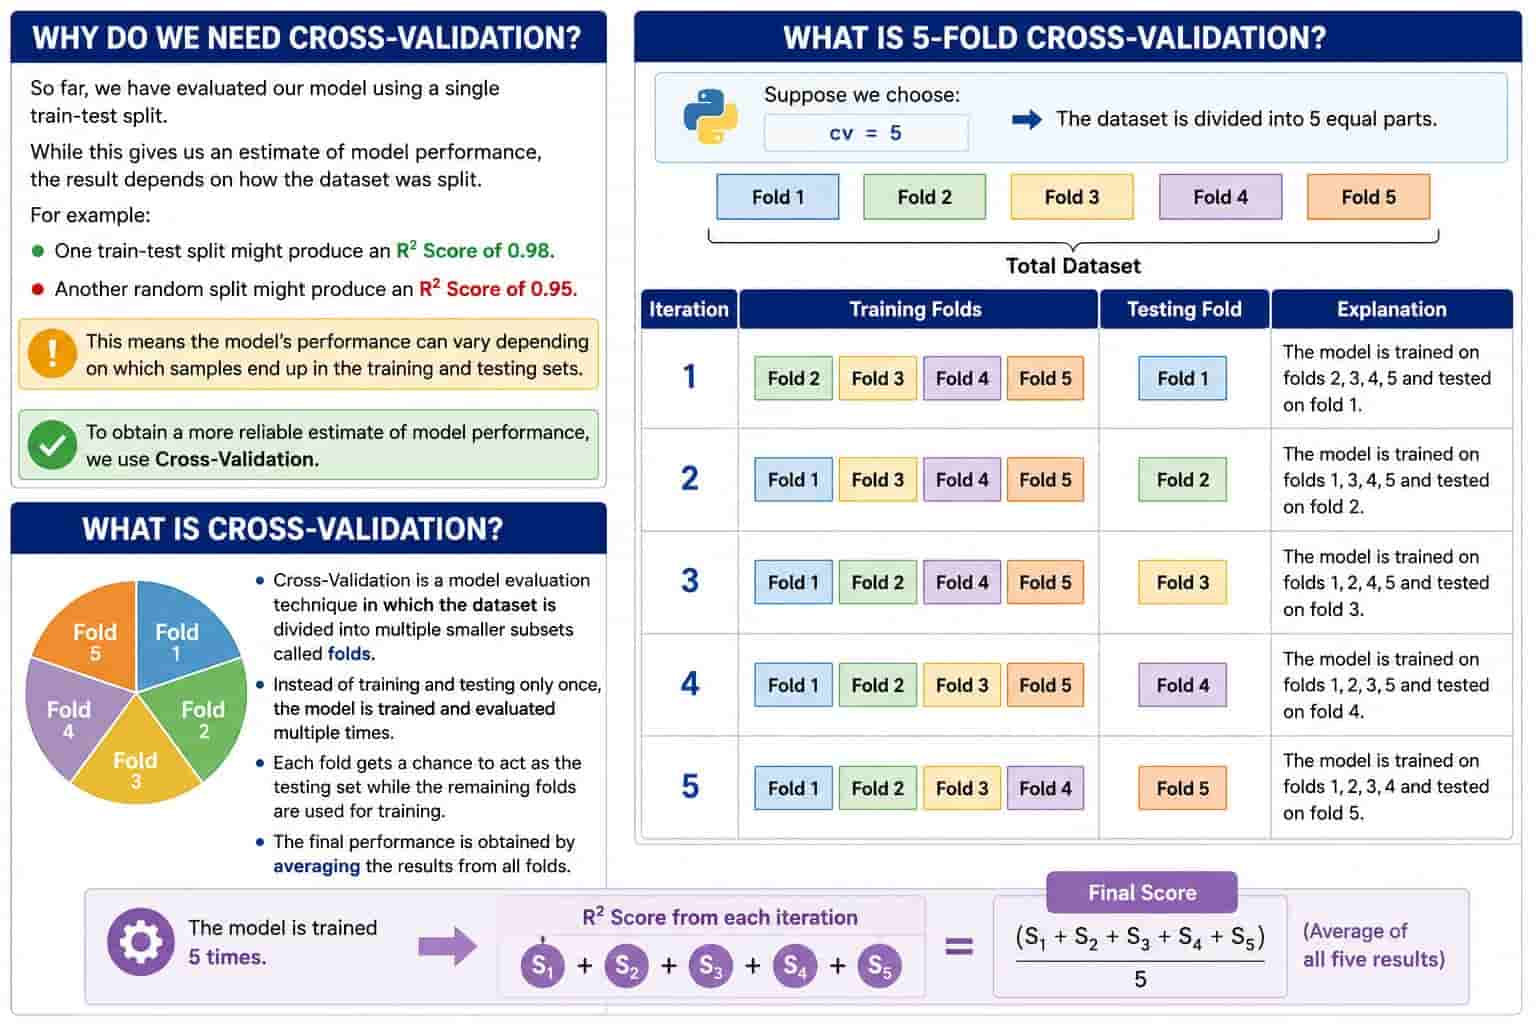

**Why are we using Cross-Validation with Lasso?**

Lasso Regression contains regularization.

Cross-validation helps us determine whether the model performs consistently across different subsets of the data instead of performing well on just one train-test split.

This provides a more reliable estimate of the model's ability to generalize.

```
lasso_cv = LassoCV(
    eps=1e-3,
    n_alphas=100,
    alphas=None,
    fit_intercept=True,
    precompute="auto",
    max_iter=1000,
    tol=1e-4,
    copy_X=True,
    cv=5,
    verbose=False,
    n_jobs=-1,
    positive=False,
    random_state=42,
    selection="cyclic"
)
```



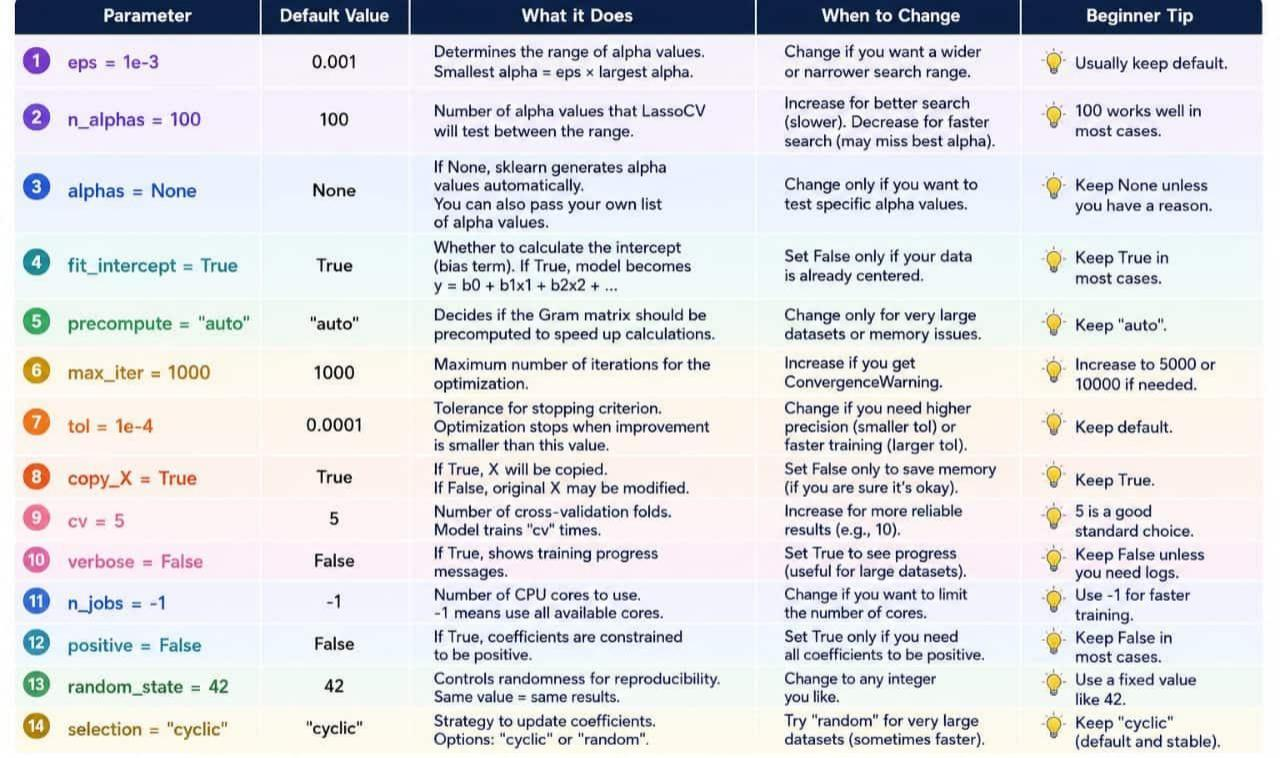

## **Train a Lasso Regression Model using Cross-Validation (LassoCV)**

**Why do we use LassoCV?**

Earlier, we trained a Lasso Regression model using the default parameters.

```python
lasso = Lasso()
```

However, Lasso Regression has an important hyperparameter called **`alpha`**.

The **alpha** parameter controls the strength of regularization.

Choosing the right alpha value is very important because:

* A very small alpha may lead to **overfitting**.
* A very large alpha may lead to **underfitting**.

Instead of manually trying different values, **LassoCV** automatically finds the optimal alpha using **Cross-Validation**.


**How does LassoCV work?**

The workflow is:

```
Different Alpha Values
        │
        ▼
Train Model using 5-Fold Cross Validation
        │
        ▼
Compute Validation Error
        │
        ▼
Select Alpha with Lowest Average Error
        │
        ▼
Train Final Lasso Model using Best Alpha
```

This automatic tuning often results in a model that generalizes better than using the default alpha.

In [ ]:
from sklearn.linear_model import LassoCV

# Initialize the LassoCV model
lasso_cv = LassoCV(
    cv=5,
    random_state=42
)

# Train the model
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(cv=5, random_state=42)

The model:

* Tries multiple alpha values.
* Performs 5-fold cross-validation for every alpha.
* Computes the average validation error.
* Selects the alpha with the lowest average error.
* Trains the final model using the entire training dataset and the selected alpha.

**Find the Best Alpha**

After training, display the selected alpha:

In [ ]:
print("Best Alpha:", lasso_cv.alpha_)

Best Alpha: 0.05725391318234408


This means that after evaluating many different alpha values through 5-fold cross-validation, the model determined that **0.05725391318234408** provides the best balance between model complexity and prediction accuracy.

This alpha value minimizes the average validation error.

In [ ]:
# Make Predictions
lasso_cv_pred = lasso_cv.predict(X_test_scaled)

In [ ]:
# Evaluate the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lasso_cv_mae = mean_absolute_error(y_test, lasso_cv_pred)
lasso_cv_mse = mean_squared_error(y_test, lasso_cv_pred)
lasso_cv_rmse = np.sqrt(lasso_cv_mse)
lasso_cv_r2 = r2_score(y_test, lasso_cv_pred)

print(f"Best Alpha              : {lasso_cv.alpha_:.6f}")
print(f"Mean Absolute Error     : {lasso_cv_mae:.3f}")
print(f"Mean Squared Error      : {lasso_cv_mse:.3f}")
print(f"Root Mean Squared Error : {lasso_cv_rmse:.3f}")
print(f"R² Score                : {lasso_cv_r2:.3f}")

Best Alpha              : 0.057254
Mean Absolute Error     : 0.620
Mean Squared Error      : 0.792
Root Mean Squared Error : 0.890
R² Score                : 0.982


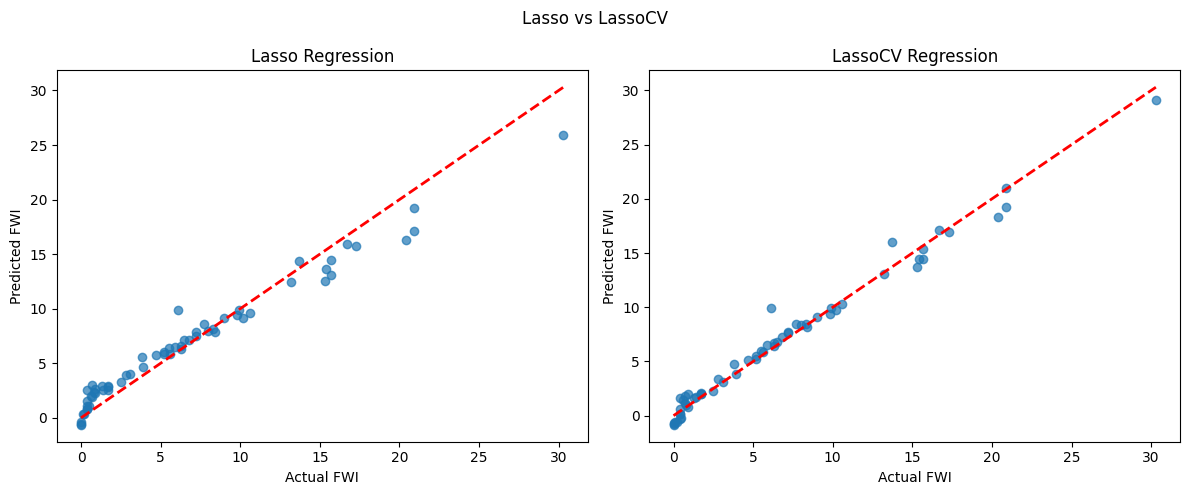

In [ ]:
# Predictions
lasso_pred = lasso.predict(X_test_scaled)
lasso_cv_pred = lasso_cv.predict(X_test_scaled)

plt.figure(figsize=(12,5))

# Lasso
plt.subplot(1,2,1)

plt.scatter(y_test, lasso_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("Lasso Regression")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

# LassoCV
plt.subplot(1,2,2)

plt.scatter(y_test, lasso_cv_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("LassoCV Regression")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

plt.suptitle("Lasso vs LassoCV")
plt.tight_layout()

plt.show()


### **Observations**

* The left plot shows the predictions made by the **Lasso Regression** model, while the right plot shows the predictions made by the **LassoCV** model.
* In both plots, each blue point represents one sample from the **test dataset**.
* The **x-axis** represents the **actual Fire Weather Index (FWI)**, and the **y-axis** represents the **predicted Fire Weather Index (FWI)**.
* The red dashed line represents the **ideal prediction line**, where the predicted value is exactly equal to the actual value.
* In both models, most data points lie close to the red dashed line, indicating that both models have learned the relationship between the input features and the target variable effectively.
* Compared to the standard Lasso model, the **LassoCV** model has points that are slightly closer to the reference line for many samples, suggesting a small improvement in prediction accuracy.
* This improvement is because **LassoCV automatically selects the optimal alpha value using 5-Fold Cross-Validation**, whereas the standard Lasso model uses the default alpha value.
* There are only a few points that deviate noticeably from the reference line, indicating that both models make only small prediction errors on most test samples.

---

### **Conclusion**

> Both **Lasso Regression** and **LassoCV** perform well on this dataset. However, **LassoCV** is generally preferred because it automatically finds the optimal regularization strength (`alpha`) using cross-validation. As a result, its predictions are slightly closer to the actual values, leading to better generalization and improved performance on unseen data.

> *"In this dataset, LassoCV provides slightly better predictions because it automatically selected an optimal alpha value through cross-validation. On a different dataset, the improvement may be smaller or, in some cases, the default Lasso model may perform similarly."*


**Performance Comparison**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

comparison = pd.DataFrame({
    "Model":[
        "Lasso",
        "LassoCV"
    ],

    "Alpha":[
        lasso.alpha,
        lasso_cv.alpha_
    ],

    "MAE":[
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, lasso_cv_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_cv_pred))
    ],

    "R² Score":[
        r2_score(y_test, lasso_pred),
        r2_score(y_test, lasso_cv_pred)
    ]
})

comparison

,Model,Alpha,MAE,RMSE,R² Score
0,Lasso,1.000000,1.133176,1.499449,0.949202
1,LassoCV,0.057254,0.619970,0.890224,0.982095


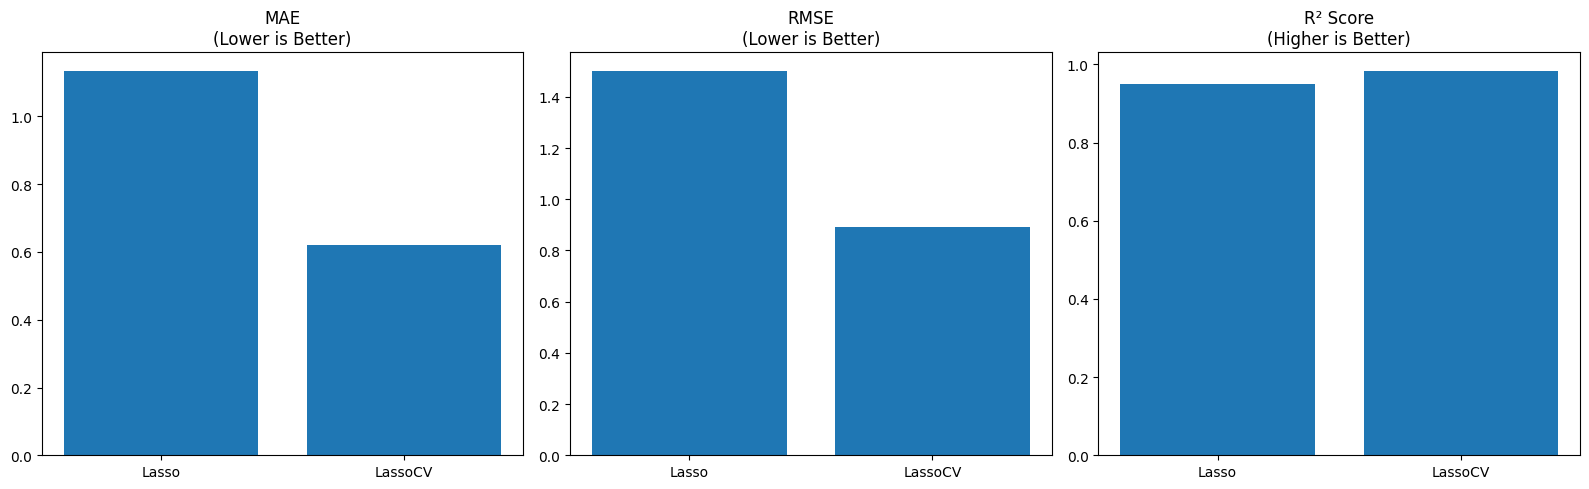

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

# MAE
axes[0].bar(comparison["Model"], comparison["MAE"])
axes[0].set_title("MAE\n(Lower is Better)")

# RMSE
axes[1].bar(comparison["Model"], comparison["RMSE"])
axes[1].set_title("RMSE\n(Lower is Better)")

# R²
axes[2].bar(comparison["Model"], comparison["R² Score"])
axes[2].set_title("R² Score\n(Higher is Better)")

plt.tight_layout()
plt.show()

**Coefficient Comparison**

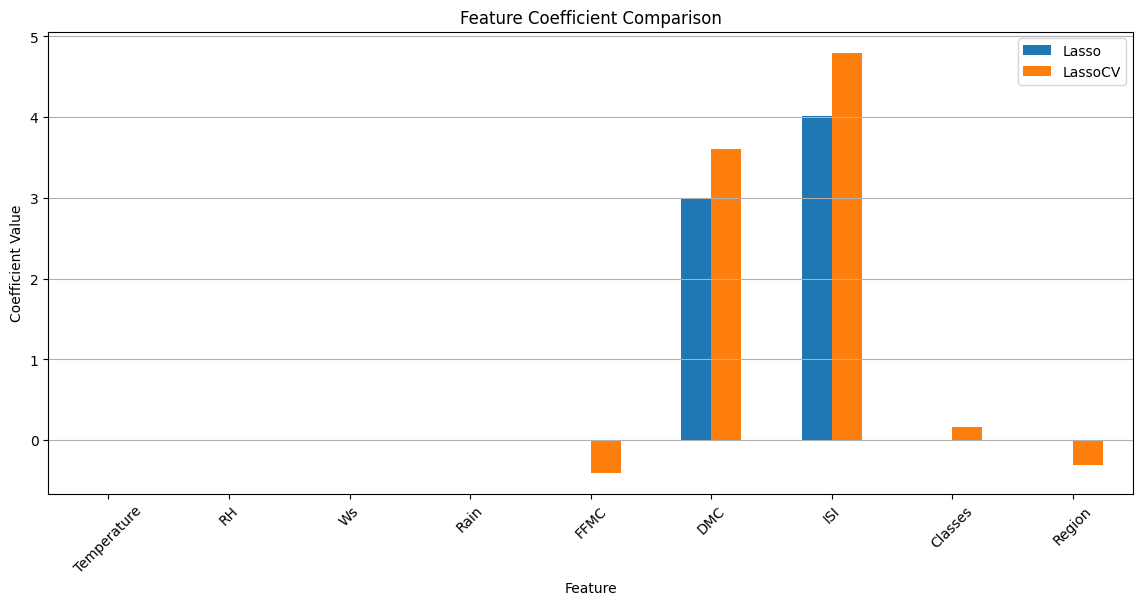

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Lasso": lasso.coef_,
    "LassoCV": lasso_cv.coef_
})

coef_df = coef_df.set_index("Feature")

coef_df.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Feature Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

This visualization shows:

* Which features have been shrunk toward zero.
* How LassoCV changes the coefficients compared to the default Lasso model.
* Whether different alpha values affect feature importance.

Default Lasso Alpha : 1.0
Best Alpha from LassoCV : 0.057254


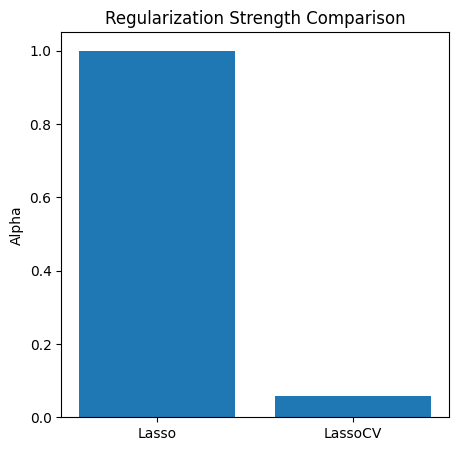

In [ ]:
# Alpha Comparison
print(f"Default Lasso Alpha : {lasso.alpha}")
print(f"Best Alpha from LassoCV : {lasso_cv.alpha_:.6f}")

plt.figure(figsize=(5,5))

plt.bar(
    ["Lasso", "LassoCV"],
    [lasso.alpha, lasso_cv.alpha_]
)

plt.ylabel("Alpha")
plt.title("Regularization Strength Comparison")

plt.show()

**What are Alpha Values?**

The **alpha** parameter controls the strength of regularization in Lasso Regression.

Instead of testing only one alpha value, **LassoCV automatically generates and evaluates multiple alpha values**.

By default, `LassoCV` tests **100 different alpha values** (unless specified otherwise).

For each alpha value, it performs **Cross-Validation**, computes the validation error, and finally selects the alpha that gives the best performance.


**Small Alpha**

* Less penalty
* Larger coefficients
* Higher model complexity

**Large Alpha**

* Strong penalty
* Smaller coefficients
* Simpler model

**Best Alpha**

* Found automatically using Cross Validation
* Gives the best validation performance

In [ ]:
# Display all alpha values tested during Cross-Validation
lasso_cv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

**Observations**

* By default, **100 alpha values** are generated.
* These values are arranged from **largest to smallest**.
* Each alpha value is evaluated using **5-Fold Cross-Validation**.
* Later, the alpha with the **lowest average validation error** is selected automatically.

**Why is this important?**

Instead of manually trying different alpha values, `LassoCV` performs the search automatically, saving time and helping us choose a better-performing model.


## **View the Cross-Validation Error for Each Alpha**

**What is `mse_path_`?**

After testing every alpha value, `LassoCV` stores the **Mean Squared Error (MSE)** obtained during each fold of Cross-Validation.

This information is stored in: `mse_path_`

In [ ]:
# Display the Mean Squared Error for every alpha value
lasso_cv.mse_path_

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

The array helps us understand how the model performed for every tested alpha.

In [ ]:
lasso_cv.mse_path_.shape

(100, 5)

This means:

* **100** → Number of alpha values tested.
* **5** → Number of Cross-Validation folds (`cv=5`).

Each row represents one alpha value, and each column represents the MSE obtained for one fold.

For example:

| Alpha | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 |
| ----- | -----: | -----: | -----: | -----: | -----: |
| α₁    |   0.82 |   0.85 |   0.80 |   0.84 |   0.81 |
| α₂    |   0.78 |   0.79 |   0.77 |   0.80 |   0.78 |
| ...   |    ... |    ... |    ... |    ... |    ... |

---

**Why is this important?**

The model computes the **average MSE across all folds** for each alpha.

The alpha with the **lowest average MSE** is selected as the optimal alpha.

Rows represent different alpha values, while columns represent different folds used during cross-validation.

# **Model Comparison**

Compare the performance of Lasso Regression and LassoCV using the evaluation metrics below.

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Lasso", "LassoCV"],
    "Alpha": [lasso.alpha, lasso_cv.alpha_],
    "MAE": [lasso_mae, lasso_cv_mae],
    "MSE": [lasso_mse, lasso_cv_mse],
    "RMSE": [lasso_rmse, lasso_cv_rmse],
    "R² Score": [lasso_r2, lasso_cv_r2]
})

comparison_df

,Model,Alpha,MAE,MSE,RMSE,R² Score
0,Lasso,1.000000,1.133176,2.248346,1.499449,0.949202
1,LassoCV,0.057254,0.619970,0.792500,0.890224,0.982095


LassoCV automatically selected the optimal value of alpha using 5-fold Cross Validation. By comparing the evaluation metrics, we can determine whether automatic hyperparameter tuning improves the model's predictive performance over manually selecting alpha.

In [ ]:
best_model = comparison.loc[
    comparison["R² Score"].idxmax(),
    "Model"
]

print(f"Best Performing Model: {best_model}")

Best Performing Model: LassoCV


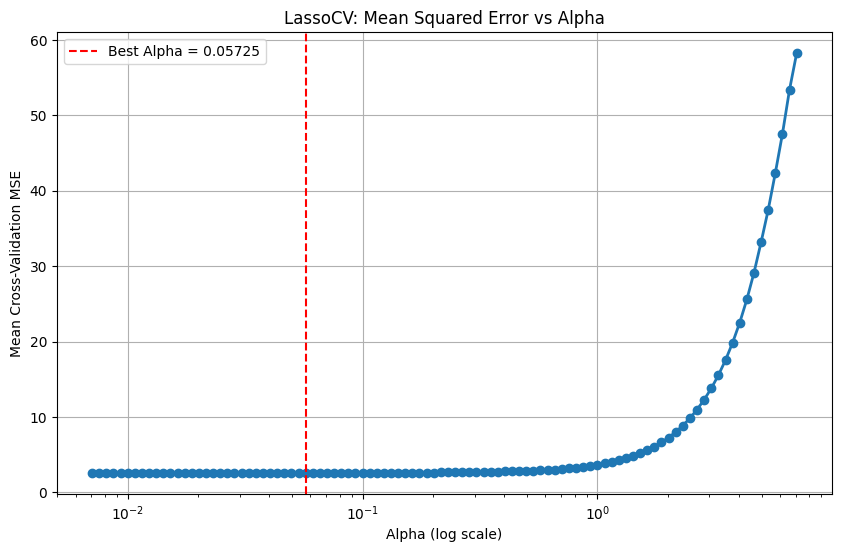

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the average MSE across all folds
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    lasso_cv.alphas_,
    mean_mse,
    marker='o',
    linewidth=2
)

# Highlight the best alpha
plt.axvline(
    lasso_cv.alpha_,
    color='red',
    linestyle='--',
    label=f'Best Alpha = {lasso_cv.alpha_:.5f}'
)

plt.xscale("log")

plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("LassoCV: Mean Squared Error vs Alpha")

plt.legend()
plt.grid(True)

plt.show()

**Observations**

From this graph, we can observe that:

* Each point represents an **alpha value** tested by `LassoCV`.
* The **y-axis** shows the **average Mean Squared Error (MSE)** across all 5 folds.
* The **red dashed line** indicates the **best alpha** selected by the model.
* The best alpha corresponds to the point where the average validation error is **lowest**.
* Alpha values that are too small or too large generally produce higher errors, while the selected alpha provides the best balance between model complexity and prediction accuracy.
